# 🧠 RecycleVision — Model Training (5 Transfer Learning Models)
**Project:** Garbage Image Classification Using Deep Learning  
**Notebook:** 03_Model_Training.ipynb  
**Models:** MobileNetV2 | EfficientNetB0 | ResNet50 | VGG16 | InceptionV3  
**Goal:** Train all 5 models and save them for evaluation

## 🔲 Cell 1 — Import Libraries

In [9]:
# Cell 1 - Import Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

# Transfer Learning Models
from tensorflow.keras.applications import (
    MobileNetV2,
    EfficientNetB0,
    ResNet50,
    VGG16,
    InceptionV3
)
from tensorflow.keras.applications.mobilenet_v2   import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet   import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50       import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16          import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.inception_v3   import preprocess_input as inception_preprocess

print('✅ All libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   Keras version      : {keras.__version__}')

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'   GPU available      : {gpus[0].name}')
else:
    print('   GPU available      : No GPU — using CPU')

✅ All libraries imported successfully!
   TensorFlow version : 2.21.0
   Keras version      : 3.13.2
   GPU available      : No GPU — using CPU


## 🔲 Cell 2 — Set Paths & Parameters

In [10]:
# Cell 2 - Set Paths & Hyperparameters

# Paths
TRAIN_PATH  = r"D:\RecycleVision\data\processed\train"
VAL_PATH    = r"D:\RecycleVision\data\processed\val"
TEST_PATH   = r"D:\RecycleVision\data\processed\test"
MODELS_PATH = r"D:\RecycleVision\models"
os.makedirs(MODELS_PATH, exist_ok=True)

# Hyperparameters
IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 0.0001
NUM_CLASSES = 6

# Class names
CLASSES = sorted(os.listdir(TRAIN_PATH))

print('=' * 50)
print('   ⚙️  TRAINING CONFIGURATION')
print('=' * 50)
print(f'   Image size    : {IMG_SIZE}')
print(f'   Batch size    : {BATCH_SIZE}')
print(f'   Max epochs    : {EPOCHS}')
print(f'   Learning rate : {LR}')
print(f'   Num classes   : {NUM_CLASSES}')
print(f'   Classes       : {CLASSES}')
print(f'   Models saved  : {MODELS_PATH}')
print('=' * 50)

   ⚙️  TRAINING CONFIGURATION
   Image size    : (224, 224)
   Batch size    : 32
   Max epochs    : 20
   Learning rate : 0.0001
   Num classes   : 6
   Classes       : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
   Models saved  : D:\RecycleVision\models


## 🔲 Cell 3 — Create Data Generators

In [11]:
# Cell 3 - Create Data Generators
# Note: preprocess_input is applied per model inside each build function
# Here we create a base generator with rescaling only

def get_generators(preprocess_fn):
    """Create train, val, test generators for a specific model"""

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )
    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )
    test_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn
    )

    train_gen = train_datagen.flow_from_directory(
        TRAIN_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=42
    )
    val_gen = val_datagen.flow_from_directory(
        VAL_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    test_gen = test_datagen.flow_from_directory(
        TEST_PATH,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    return train_gen, val_gen, test_gen

# Test with MobileNet generator
train_gen, val_gen, test_gen = get_generators(mobilenet_preprocess)

print('=' * 50)
print('   📂 DATA GENERATOR SUMMARY')
print('=' * 50)
print(f'   Train samples   : {train_gen.samples}')
print(f'   Val   samples   : {val_gen.samples}')
print(f'   Test  samples   : {test_gen.samples}')
print(f'   Class indices   : {train_gen.class_indices}')
print('=' * 50)

Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.
   📂 DATA GENERATOR SUMMARY
   Train samples   : 3000
   Val   samples   : 378
   Test  samples   : 383
   Class indices   : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## 🔲 Cell 4 — Helper: Build Model & Train Function

In [12]:
# Cell 4 - Helper Functions

# Store all results
all_histories = {}
all_models    = {}

def get_callbacks(model_name):
    """Define callbacks for training"""
    checkpoint_path = os.path.join(MODELS_PATH, f'{model_name}_best.h5')

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]
    return callbacks


def plot_history(history, model_name):
    """Plot training and validation accuracy/loss"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#22d3ee', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#f472b6', linewidth=2)
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='#22d3ee', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#f472b6', linewidth=2)
    axes[1].set_title(f'{model_name} — Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'📈 {model_name} Training History', fontsize=15, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(MODELS_PATH, f'{model_name}_history.png')
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'   ✅ History plot saved: {save_path}')


print('✅ Helper functions defined!')
print('   → get_callbacks()  : EarlyStopping + ModelCheckpoint + ReduceLROnPlateau')
print('   → plot_history()   : Accuracy & Loss curves')

✅ Helper functions defined!
   → get_callbacks()  : EarlyStopping + ModelCheckpoint + ReduceLROnPlateau
   → plot_history()   : Accuracy & Loss curves


## 🔲 Cell 5 — Model 1: MobileNetV2 ⚡

⚡ MODEL 1: MobileNetV2
   Total params    : 2,592,582
   Trainable params: 332,038
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training MobileNetV2...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.3143 - loss: 1.9734
Epoch 1: val_accuracy improved from None to 0.66402, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 83s 788ms/step - accuracy: 0.4257 - loss: 1.5992 - val_accuracy: 0.6640 - val_loss: 0.9681 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.6422 - loss: 1.0033
Epoch 2: val_accuracy improved from 0.66402 to 0.77778, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 71s 760ms/step - accuracy: 0.6650 - loss: 0.9389 - val_accuracy: 0.7778 - val_loss: 0.6643 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.7345 - loss: 0.7262
Epoch 3: val_accuracy improved from 0.77778 to 0.82804, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 74s 789ms/step - accuracy: 0.7430 - loss: 0.7121 - val_accuracy: 0.8280 - val_loss: 0.5614 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.7804 - loss: 0.5954
Epoch 4: val_accuracy improved from 0.82804 to 0.83862, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 779ms/step - accuracy: 0.7937 - loss: 0.5752 - val_accuracy: 0.8386 - val_loss: 0.5090 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 696ms/step - accuracy: 0.8170 - loss: 0.5318
Epoch 5: val_accuracy improved from 0.83862 to 0.84127, saving model to D:\RecycleVision\models\mobilenetv2_best.h5


...


Epoch 8: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 74s 787ms/step - accuracy: 0.8803 - loss: 0.3433 - val_accuracy: 0.8519 - val_loss: 0.4351 - learning_rate: 1.0000e-04
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9048 - loss: 0.2981
Epoch 9: val_accuracy improved from 0.85185 to 0.85450, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 9: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 75s 794ms/step - accuracy: 0.9040 - loss: 0.2969 - val_accuracy: 0.8545 - val_loss: 0.4257 - learning_rate: 1.0000e-04
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.9074 - loss: 0.2743
Epoch 10: val_accuracy improved from 0.85450 to 0.86243, saving model to D:\RecycleVision\models\mobilenetv2_best.h5



Epoch 10: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 781ms/step - accuracy: 0.9000 - loss: 0.2767 - val_accuracy: 0.8624 - val_loss: 0.4170 - learning_rate: 1.0000e-04
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.9170 - loss: 0.2337
Epoch 11: val_accuracy did not improve from 0.86243
94/94 ━━━━━━━━━━━━━━━━━━━━ 74s 789ms/step - accuracy: 0.9167 - loss: 0.2428 - val_accuracy: 0.8545 - val_loss: 0.4080 - learning_rate: 1.0000e-04
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.9233 - loss: 0.2159
Epoch 12: val_accuracy did not improve from 0.86243
94/94 ━━━━━━━━━━━━━━━━━━━━ 75s 801ms/step - accuracy: 0.9243 - loss: 0.2222 - val_accuracy: 0.8545 - val_loss: 0.4037 - learning_rate: 1.0000e-04
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.9434 - loss: 0.1839
Epoch 13: val_accuracy did not improve from 0.86243
94/94 ━━━━━━━━━━━━━━━━━━━━ 82s 870ms/step - accuracy: 0.9383 - lo


Epoch 14: finished saving model to D:\RecycleVision\models\mobilenetv2_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 80s 848ms/step - accuracy: 0.9463 - loss: 0.1746 - val_accuracy: 0.8704 - val_loss: 0.3890 - learning_rate: 1.0000e-04
Epoch 15/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.9509 - loss: 0.1621
Epoch 15: val_accuracy did not improve from 0.87037
94/94 ━━━━━━━━━━━━━━━━━━━━ 77s 820ms/step - accuracy: 0.9507 - loss: 0.1669 - val_accuracy: 0.8651 - val_loss: 0.3914 - learning_rate: 1.0000e-04
Epoch 16/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.9520 - loss: 0.1655
Epoch 16: val_accuracy did not improve from 0.87037
94/94 ━━━━━━━━━━━━━━━━━━━━ 77s 819ms/step - accuracy: 0.9467 - loss: 0.1690 - val_accuracy: 0.8598 - val_loss: 0.3864 - learning_rate: 1.0000e-04
Epoch 17/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.9608 - loss: 0.1381
Epoch 17: val_accuracy did not improve from 0.87037
94/94 ━━━━━━━━━━━━━━━━━━━━ 76s 807ms/step - accuracy: 0.9603 - lo


✅ MobileNetV2 Training Complete!
   Best Train Accuracy : 0.9680 (96.80%)
   Best Val Accuracy   : 0.8704 (87.04%)
   Model saved         : D:\RecycleVision\models\mobilenetv2_model.h5


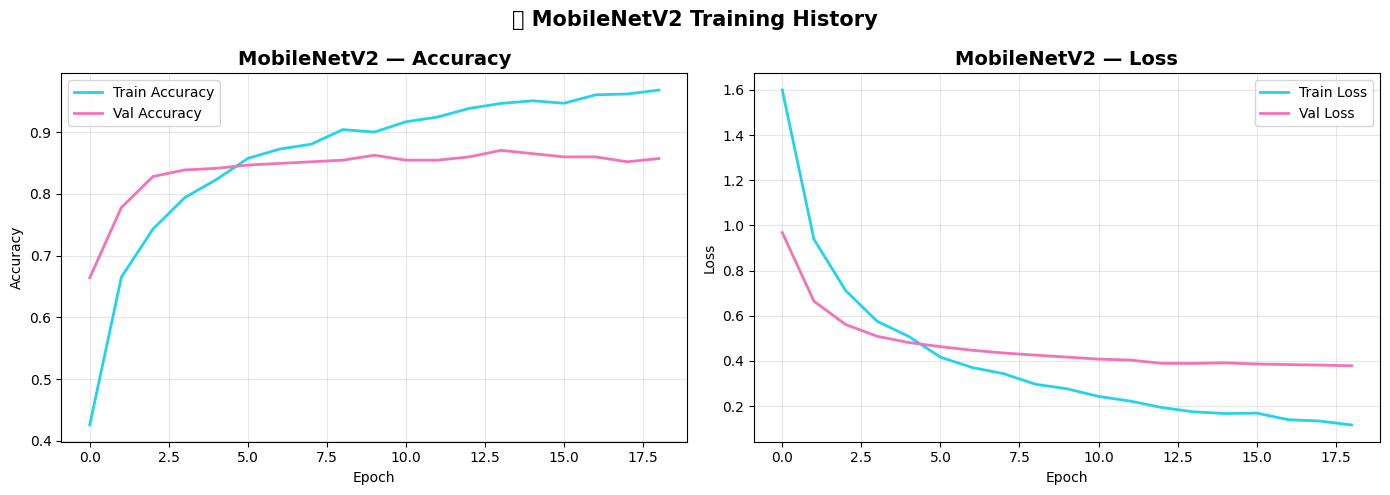

   ✅ History plot saved: D:\RecycleVision\models\MobileNetV2_history.png


In [13]:
# Cell 5 - Model 1: MobileNetV2
print('=' * 55)
print('⚡ MODEL 1: MobileNetV2')
print('=' * 55)

# --- Build Model ---
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False  # Freeze base layers

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_model = keras.Model(inputs, outputs, name='MobileNetV2')
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {mobilenet_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in mobilenet_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(mobilenet_preprocess)

# --- Train ---
print('\n🚀 Training MobileNetV2...')
mobilenet_history = mobilenet_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('mobilenetv2'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'mobilenetv2_model.h5')
mobilenet_model.save(save_path)

# --- Results ---
best_val_acc = max(mobilenet_history.history['val_accuracy'])
best_train_acc = max(mobilenet_history.history['accuracy'])
all_histories['MobileNetV2'] = mobilenet_history
all_models['MobileNetV2']    = mobilenet_model

print(f'\n✅ MobileNetV2 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(mobilenet_history, 'MobileNetV2')

## 🔲 Cell 6 — Model 2: EfficientNetB0 🎯

🎯 MODEL 2: EfficientNetB0
   Total params    : 4,384,169
   Trainable params: 332,038
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training EfficientNetB0...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 870ms/step - accuracy: 0.3315 - loss: 2.0573
Epoch 1: val_accuracy improved from None to 0.76190, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.4660 - loss: 1.5661 - val_accuracy: 0.7619 - val_loss: 0.8852 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.6908 - loss: 0.8469
Epoch 2: val_accuracy improved from 0.76190 to 0.83862, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.7180 - loss: 0.7807 - val_accuracy: 0.8386 - val_loss: 0.5574 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.7887 - loss: 0.5684
Epoch 3: val_accuracy improved from 0.83862 to 0.84921, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.7960 - loss: 0.5754 - val_accuracy: 0.8492 - val_loss: 0.4239 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 950ms/step - accuracy: 0.8513 - loss: 0.4512
Epoch 4: val_accuracy improved from 0.84921 to 0.86772, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8443 - loss: 0.4418 - val_accuracy: 0.8677 - val_loss: 0.3612 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - accuracy: 0.8636 - loss: 0.3776
Epoch 5: val_accuracy improved from 0.86772 to 0.87566, saving model to D:\RecycleVision\models\efficientnetb0_best.h5


...


Epoch 12: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9460 - loss: 0.1679 - val_accuracy: 0.8995 - val_loss: 0.2730 - learning_rate: 1.0000e-04
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 909ms/step - accuracy: 0.9503 - loss: 0.1525
Epoch 13: val_accuracy improved from 0.89947 to 0.90212, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 13: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9523 - loss: 0.1487 - val_accuracy: 0.9021 - val_loss: 0.2673 - learning_rate: 1.0000e-04
Epoch 14/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.9559 - loss: 0.1465
Epoch 14: val_accuracy did not improve from 0.90212
94/94 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9567 - loss: 0.1466 - val_accuracy: 0.8995 - val_loss: 0.2664 - learning_rate: 1.0000e-04
Epoch 15/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.9623 - loss: 0.1300
Epoch 15: val_accuracy improved from 0.90212 to 0.90476, saving model to D:\RecycleVision\models\efficientnetb0_best.h5



Epoch 15: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9663 - loss: 0.1258 - val_accuracy: 0.9048 - val_loss: 0.2599 - learning_rate: 1.0000e-04
Epoch 16/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.9662 - loss: 0.1248
Epoch 16: val_accuracy did not improve from 0.90476
94/94 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9637 - loss: 0.1246 - val_accuracy: 0.9048 - val_loss: 0.2605 - learning_rate: 1.0000e-04
Epoch 17/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - accuracy: 0.9682 - loss: 0.1049
Epoch 17: val_accuracy did not improve from 0.90476
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9637 - loss: 0.1094 - val_accuracy: 0.9048 - val_loss: 0.2603 - learning_rate: 1.0000e-04
Epoch 18/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.9792 - loss: 0.0889
Epoch 18: val_accuracy did not improve from 0.90476

Epoch 18: ReduceLROnPlateau reducing learning rate to 4.99999987368937


Epoch 19: finished saving model to D:\RecycleVision\models\efficientnetb0_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9740 - loss: 0.0973 - val_accuracy: 0.9074 - val_loss: 0.2600 - learning_rate: 5.0000e-05
Epoch 20/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.9768 - loss: 0.0769
Epoch 20: val_accuracy did not improve from 0.90741
94/94 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9720 - loss: 0.0903 - val_accuracy: 0.9074 - val_loss: 0.2556 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 19.



✅ EfficientNetB0 Training Complete!
   Best Train Accuracy : 0.9773 (97.73%)
   Best Val Accuracy   : 0.9074 (90.74%)
   Model saved         : D:\RecycleVision\models\efficientnetb0_model.h5


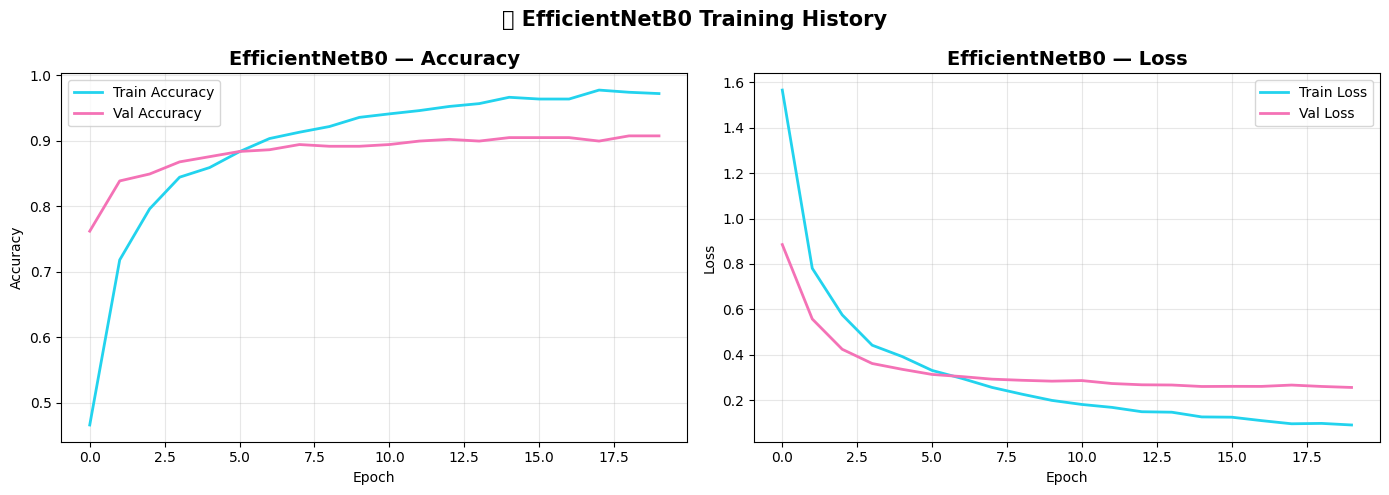

   ✅ History plot saved: D:\RecycleVision\models\EfficientNetB0_history.png


In [14]:
# Cell 6 - Model 2: EfficientNetB0
print('=' * 55)
print('🎯 MODEL 2: EfficientNetB0')
print('=' * 55)

# --- Build Model ---
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

efficientnet_model = keras.Model(inputs, outputs, name='EfficientNetB0')
efficientnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {efficientnet_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in efficientnet_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(efficientnet_preprocess)

# --- Train ---
print('\n🚀 Training EfficientNetB0...')
efficientnet_history = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('efficientnetb0'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'efficientnetb0_model.h5')
efficientnet_model.save(save_path)

# --- Results ---
best_val_acc   = max(efficientnet_history.history['val_accuracy'])
best_train_acc = max(efficientnet_history.history['accuracy'])
all_histories['EfficientNetB0'] = efficientnet_history
all_models['EfficientNetB0']    = efficientnet_model

print(f'\n✅ EfficientNetB0 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(efficientnet_history, 'EfficientNetB0')

## 🔲 Cell 7 — Model 3: ResNet50 🏗️

🏗️  MODEL 3: ResNet50
   Total params    : 24,648,070
   Trainable params: 1,056,262
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training ResNet50...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4436 - loss: 1.7147
Epoch 1: val_accuracy improved from None to 0.83069, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - accuracy: 0.5860 - loss: 1.2348 - val_accuracy: 0.8307 - val_loss: 0.5515 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.7658 - loss: 0.6584 
Epoch 2: val_accuracy improved from 0.83069 to 0.86243, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 1603s 17s/step - accuracy: 0.7900 - loss: 0.6083 - val_accuracy: 0.8624 - val_loss: 0.4102 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8375 - loss: 0.4554
Epoch 3: val_accuracy improved from 0.86243 to 0.87302, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.8410 - loss: 0.4583 - val_accuracy: 0.8730 - val_loss: 0.3539 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8885 - loss: 0.3165
Epoch 4: val_accuracy improved from 0.87302 to 0.89683, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.8960 - loss: 0.3007 - val_accuracy: 0.8968 - val_loss: 0.3253 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9062 - loss: 0.2553
Epoch 5: val_accuracy did not improve from 0.89683
94/94 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9073 - loss: 0.2578 - val_accuracy: 0.8968 - val_loss: 0.3083 - learning_rate: 1.0000e-04
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9196 - loss: 0.2308
Epoch 6: val_accuracy did not improve from 0.89683
94/94 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.9303 - loss: 0.2068 - val_accuracy: 0.8889 - val_loss: 0.3133 - learning_rate: 1.0000e-04
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9345 - loss: 0.1842
Epoch 7: val_accuracy improved from 0.89683 to 0.91270, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 7: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.9350 - loss: 0.1849 - val_accuracy: 0.9127 - val_loss: 0.2971 - learning_rate: 1.0000e-04
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9597 - loss: 0.1342
Epoch 8: val_accuracy did not improve from 0.91270
94/94 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9563 - loss: 0.1383 - val_accuracy: 0.9127 - val_loss: 0.2970 - learning_rate: 1.0000e-04
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9649 - loss: 0.1221
Epoch 9: val_accuracy improved from 0.91270 to 0.91534, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 9: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9613 - loss: 0.1313 - val_accuracy: 0.9153 - val_loss: 0.2885 - learning_rate: 1.0000e-04
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9650 - loss: 0.1169
Epoch 10: val_accuracy did not improve from 0.91534
94/94 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9680 - loss: 0.1088 - val_accuracy: 0.9153 - val_loss: 0.2944 - learning_rate: 1.0000e-04
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9829 - loss: 0.0808
Epoch 11: val_accuracy did not improve from 0.91534
94/94 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.9763 - loss: 0.0853 - val_accuracy: 0.9153 - val_loss: 0.2935 - learning_rate: 1.0000e-04
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9784 - loss: 0.0854
Epoch 12: val_accuracy did not improve from 0.91534

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
94/94 


Epoch 13: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.9803 - loss: 0.0702 - val_accuracy: 0.9286 - val_loss: 0.2880 - learning_rate: 5.0000e-05
Epoch 14/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9836 - loss: 0.0674
Epoch 14: val_accuracy did not improve from 0.92857
94/94 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.9783 - loss: 0.0742 - val_accuracy: 0.9259 - val_loss: 0.2834 - learning_rate: 5.0000e-05
Epoch 15/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9811 - loss: 0.0647
Epoch 15: val_accuracy improved from 0.92857 to 0.93122, saving model to D:\RecycleVision\models\resnet50_best.h5



Epoch 15: finished saving model to D:\RecycleVision\models\resnet50_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.9823 - loss: 0.0649 - val_accuracy: 0.9312 - val_loss: 0.2850 - learning_rate: 5.0000e-05
Epoch 16/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9817 - loss: 0.0677
Epoch 16: val_accuracy did not improve from 0.93122
94/94 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.9817 - loss: 0.0684 - val_accuracy: 0.9259 - val_loss: 0.2822 - learning_rate: 5.0000e-05
Epoch 17/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9900 - loss: 0.0507
Epoch 17: val_accuracy did not improve from 0.93122
94/94 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9883 - loss: 0.0550 - val_accuracy: 0.9286 - val_loss: 0.2862 - learning_rate: 5.0000e-05
Epoch 18/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9865 - loss: 0.0540
Epoch 18: val_accuracy did not improve from 0.93122
94/94 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.9863 - loss: 0.0535 - val_acc


✅ ResNet50 Training Complete!
   Best Train Accuracy : 0.9903 (99.03%)
   Best Val Accuracy   : 0.9312 (93.12%)
   Model saved         : D:\RecycleVision\models\resnet50_model.h5


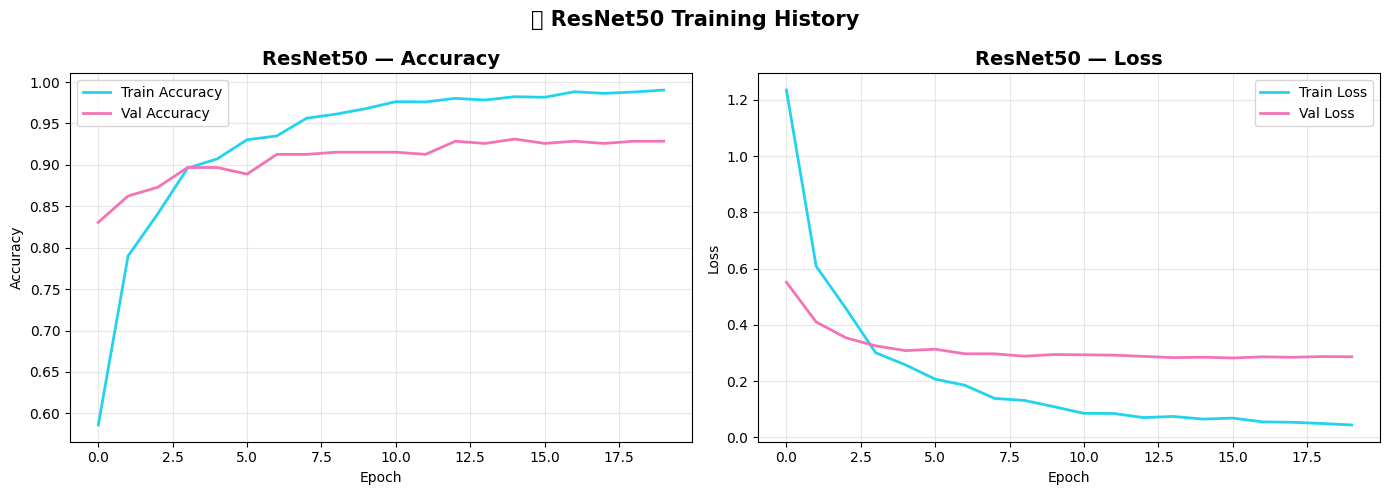

   ✅ History plot saved: D:\RecycleVision\models\ResNet50_history.png


In [15]:
# Cell 7 - Model 3: ResNet50
print('=' * 55)
print('🏗️  MODEL 3: ResNet50')
print('=' * 55)

# --- Build Model ---
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = keras.Model(inputs, outputs, name='ResNet50')
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {resnet_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in resnet_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(resnet_preprocess)

# --- Train ---
print('\n🚀 Training ResNet50...')
resnet_history = resnet_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('resnet50'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'resnet50_model.h5')
resnet_model.save(save_path)

# --- Results ---
best_val_acc   = max(resnet_history.history['val_accuracy'])
best_train_acc = max(resnet_history.history['accuracy'])
all_histories['ResNet50'] = resnet_history
all_models['ResNet50']    = resnet_model

print(f'\n✅ ResNet50 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(resnet_history, 'ResNet50')

## 🔲 Cell 8 — Model 4: VGG16 🔲

🔲 MODEL 4: VGG16
   Total params    : 27,693,126
   Trainable params: 12,978,438
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training VGG16...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3847 - loss: 7.2187
Epoch 1: val_accuracy improved from None to 0.71958, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 683s 7s/step - accuracy: 0.4720 - loss: 5.0126 - val_accuracy: 0.7196 - val_loss: 1.0023 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6728 - loss: 1.7169
Epoch 2: val_accuracy improved from 0.71958 to 0.80159, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 563s 6s/step - accuracy: 0.6847 - loss: 1.5444 - val_accuracy: 0.8016 - val_loss: 0.7006 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7802 - loss: 0.9090
Epoch 3: val_accuracy improved from 0.80159 to 0.80952, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 566s 6s/step - accuracy: 0.7793 - loss: 0.8932 - val_accuracy: 0.8095 - val_loss: 0.6468 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8168 - loss: 0.7046
Epoch 4: val_accuracy improved from 0.80952 to 0.81746, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 565s 6s/step - accuracy: 0.8363 - loss: 0.6076 - val_accuracy: 0.8175 - val_loss: 0.7172 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8776 - loss: 0.4228
Epoch 5: val_accuracy improved from 0.81746 to 0.83069, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 5: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 564s 6s/step - accuracy: 0.8757 - loss: 0.4367 - val_accuracy: 0.8307 - val_loss: 0.6474 - learning_rate: 1.0000e-04
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8884 - loss: 0.4721
Epoch 6: val_accuracy improved from 0.83069 to 0.86243, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 6: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 566s 6s/step - accuracy: 0.8853 - loss: 0.4521 - val_accuracy: 0.8624 - val_loss: 0.5350 - learning_rate: 1.0000e-04
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9202 - loss: 0.2715
Epoch 7: val_accuracy did not improve from 0.86243
94/94 ━━━━━━━━━━━━━━━━━━━━ 547s 6s/step - accuracy: 0.9190 - loss: 0.3190 - val_accuracy: 0.8545 - val_loss: 0.6091 - learning_rate: 1.0000e-04
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9203 - loss: 0.3233
Epoch 8: val_accuracy did not improve from 0.86243
94/94 ━━━━━━━━━━━━━━━━━━━━ 548s 6s/step - accuracy: 0.9167 - loss: 0.3063 - val_accuracy: 0.8571 - val_loss: 0.6375 - learning_rate: 1.0000e-04
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9382 - loss: 0.2397
Epoch 9: val_accuracy improved from 0.86243 to 0.86772, saving model to D:\RecycleVision\models\vgg16_best.h5



Epoch 9: finished saving model to D:\RecycleVision\models\vgg16_best.h5

Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
94/94 ━━━━━━━━━━━━━━━━━━━━ 534s 6s/step - accuracy: 0.9320 - loss: 0.2663 - val_accuracy: 0.8677 - val_loss: 0.6494 - learning_rate: 1.0000e-04
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9315 - loss: 0.2454
Epoch 10: val_accuracy did not improve from 0.86772
94/94 ━━━━━━━━━━━━━━━━━━━━ 535s 6s/step - accuracy: 0.9363 - loss: 0.2386 - val_accuracy: 0.8571 - val_loss: 0.6108 - learning_rate: 5.0000e-05
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9505 - loss: 0.2184
Epoch 11: val_accuracy did not improve from 0.86772
94/94 ━━━━━━━━━━━━━━━━━━━━ 535s 6s/step - accuracy: 0.9533 - loss: 0.1860 - val_accuracy: 0.8651 - val_loss: 0.5972 - learning_rate: 5.0000e-05
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9596 - loss: 0.1321
Epoch 12: val_accuracy did not improve from 0.86772

Epoch 12:


Epoch 13: finished saving model to D:\RecycleVision\models\vgg16_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 536s 6s/step - accuracy: 0.9610 - loss: 0.1510 - val_accuracy: 0.8757 - val_loss: 0.6221 - learning_rate: 2.5000e-05
Epoch 14/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9647 - loss: 0.1302
Epoch 14: val_accuracy did not improve from 0.87566
94/94 ━━━━━━━━━━━━━━━━━━━━ 551s 6s/step - accuracy: 0.9633 - loss: 0.1452 - val_accuracy: 0.8677 - val_loss: 0.6270 - learning_rate: 2.5000e-05
Epoch 15/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9706 - loss: 0.0981
Epoch 15: val_accuracy did not improve from 0.87566

Epoch 15: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
94/94 ━━━━━━━━━━━━━━━━━━━━ 31623s 340s/step - accuracy: 0.9683 - loss: 0.1113 - val_accuracy: 0.8677 - val_loss: 0.6496 - learning_rate: 2.5000e-05
Epoch 16/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9665 - loss: 0.1452
Epoch 16: val_accuracy did not improve from 0.87566
94/9


✅ VGG16 Training Complete!
   Best Train Accuracy : 0.9757 (97.57%)
   Best Val Accuracy   : 0.8757 (87.57%)
   Model saved         : D:\RecycleVision\models\vgg16_model.h5


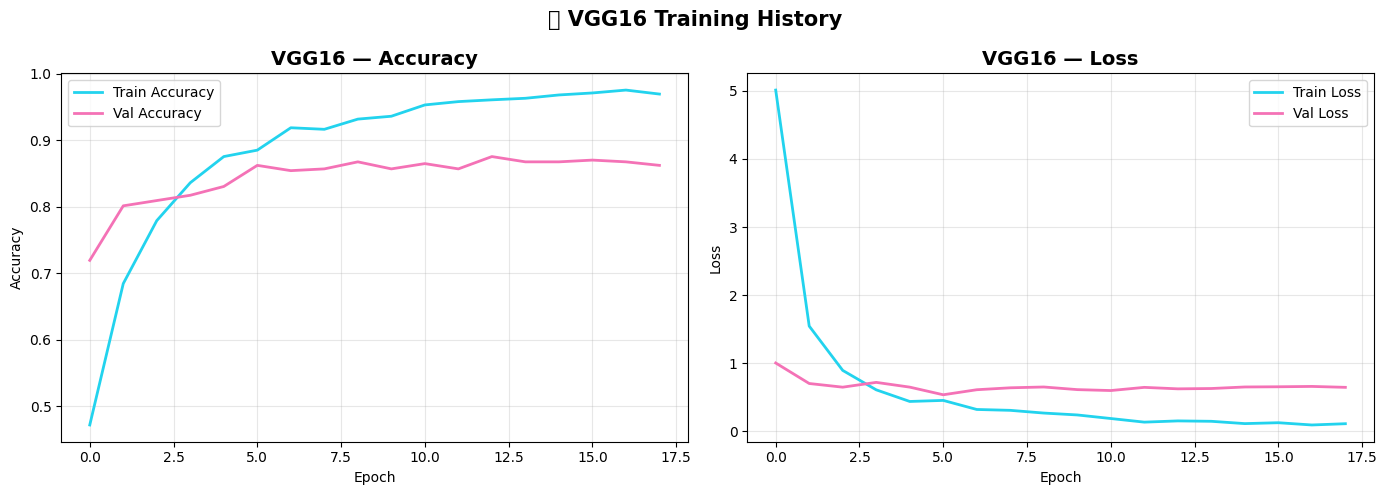

   ✅ History plot saved: D:\RecycleVision\models\VGG16_history.png


In [16]:
# Cell 8 - Model 4: VGG16
print('=' * 55)
print('🔲 MODEL 4: VGG16')
print('=' * 55)

# --- Build Model ---
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.Flatten()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

vgg16_model = keras.Model(inputs, outputs, name='VGG16')
vgg16_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {vgg16_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in vgg16_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(vgg16_preprocess)

# --- Train ---
print('\n🚀 Training VGG16...')
vgg16_history = vgg16_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('vgg16'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'vgg16_model.h5')
vgg16_model.save(save_path)

# --- Results ---
best_val_acc   = max(vgg16_history.history['val_accuracy'])
best_train_acc = max(vgg16_history.history['accuracy'])
all_histories['VGG16'] = vgg16_history
all_models['VGG16']    = vgg16_model

print(f'\n✅ VGG16 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(vgg16_history, 'VGG16')

## 🔲 Cell 9 — Model 5: InceptionV3 🌀

🌀 MODEL 5: InceptionV3
   Total params    : 22,863,142
   Trainable params: 1,056,262
Found 3000 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.

🚀 Training InceptionV3...
Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4271 - loss: 1.7597
Epoch 1: val_accuracy improved from None to 0.74339, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 1: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.5587 - loss: 1.2949 - val_accuracy: 0.7434 - val_loss: 0.6978 - learning_rate: 1.0000e-04
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7645 - loss: 0.6622
Epoch 2: val_accuracy improved from 0.74339 to 0.78836, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 2: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.7663 - loss: 0.6650 - val_accuracy: 0.7884 - val_loss: 0.5667 - learning_rate: 1.0000e-04
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8327 - loss: 0.4683
Epoch 3: val_accuracy improved from 0.78836 to 0.80688, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 3: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8373 - loss: 0.4659 - val_accuracy: 0.8069 - val_loss: 0.5221 - learning_rate: 1.0000e-04
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8681 - loss: 0.3633
Epoch 4: val_accuracy improved from 0.80688 to 0.81746, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 4: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.8783 - loss: 0.3433 - val_accuracy: 0.8175 - val_loss: 0.4871 - learning_rate: 1.0000e-04
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9126 - loss: 0.2767
Epoch 5: val_accuracy did not improve from 0.81746
94/94 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9043 - loss: 0.2836 - val_accuracy: 0.8175 - val_loss: 0.4751 - learning_rate: 1.0000e-04
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9292 - loss: 0.2133
Epoch 6: val_accuracy improved from 0.81746 to 0.83333, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 6: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 425s 5s/step - accuracy: 0.9273 - loss: 0.2208 - val_accuracy: 0.8333 - val_loss: 0.4736 - learning_rate: 1.0000e-04
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9499 - loss: 0.1708
Epoch 7: val_accuracy did not improve from 0.83333
94/94 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.9463 - loss: 0.1826 - val_accuracy: 0.8307 - val_loss: 0.4698 - learning_rate: 1.0000e-04
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9518 - loss: 0.1516
Epoch 8: val_accuracy improved from 0.83333 to 0.83862, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 8: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9563 - loss: 0.1476 - val_accuracy: 0.8386 - val_loss: 0.4730 - learning_rate: 1.0000e-04
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9708 - loss: 0.1182
Epoch 9: val_accuracy improved from 0.83862 to 0.84392, saving model to D:\RecycleVision\models\inceptionv3_best.h5



Epoch 9: finished saving model to D:\RecycleVision\models\inceptionv3_best.h5
94/94 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9650 - loss: 0.1278 - val_accuracy: 0.8439 - val_loss: 0.4636 - learning_rate: 1.0000e-04
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9699 - loss: 0.1079
Epoch 10: val_accuracy did not improve from 0.84392
94/94 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9713 - loss: 0.1051 - val_accuracy: 0.8307 - val_loss: 0.4860 - learning_rate: 1.0000e-04
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9721 - loss: 0.1030
Epoch 11: val_accuracy did not improve from 0.84392
94/94 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9733 - loss: 0.0983 - val_accuracy: 0.8360 - val_loss: 0.4799 - learning_rate: 1.0000e-04
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9861 - loss: 0.0834
Epoch 12: val_accuracy did not improve from 0.84392

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
94/


✅ InceptionV3 Training Complete!
   Best Train Accuracy : 0.9867 (98.67%)
   Best Val Accuracy   : 0.8439 (84.39%)
   Model saved         : D:\RecycleVision\models\inceptionv3_model.h5


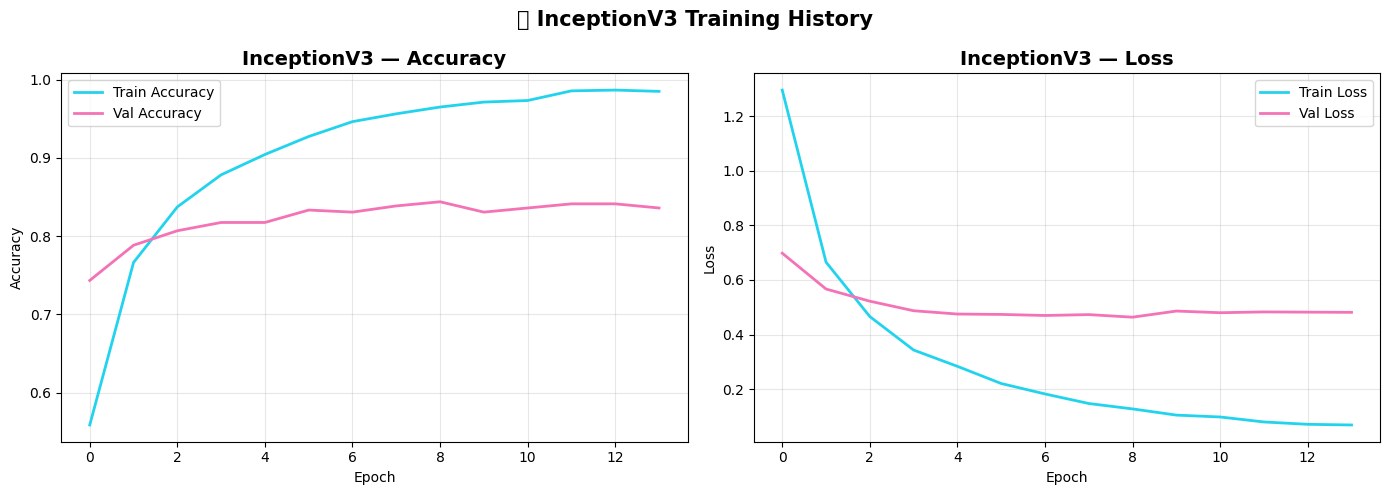

   ✅ History plot saved: D:\RecycleVision\models\InceptionV3_history.png


In [17]:
# Cell 9 - Model 5: InceptionV3
# Note: InceptionV3 requires minimum 75x75 input — we use 224x224 which is fine
print('=' * 55)
print('🌀 MODEL 5: InceptionV3')
print('=' * 55)

# --- Build Model ---
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SHAPE
)
base_model.trainable = False

inputs  = keras.Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

inception_model = keras.Model(inputs, outputs, name='InceptionV3')
inception_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'   Total params    : {inception_model.count_params():,}')
print(f'   Trainable params: {sum([tf.size(w).numpy() for w in inception_model.trainable_weights]):,}')

# --- Data Generators ---
train_gen, val_gen, test_gen = get_generators(inception_preprocess)

# --- Train ---
print('\n🚀 Training InceptionV3...')
inception_history = inception_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('inceptionv3'),
    verbose=1
)

# --- Save Model ---
save_path = os.path.join(MODELS_PATH, 'inceptionv3_model.h5')
inception_model.save(save_path)

# --- Results ---
best_val_acc   = max(inception_history.history['val_accuracy'])
best_train_acc = max(inception_history.history['accuracy'])
all_histories['InceptionV3'] = inception_history
all_models['InceptionV3']    = inception_model

print(f'\n✅ InceptionV3 Training Complete!')
print(f'   Best Train Accuracy : {best_train_acc:.4f} ({best_train_acc*100:.2f}%)')
print(f'   Best Val Accuracy   : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
print(f'   Model saved         : {save_path}')

# --- Plot ---
plot_history(inception_history, 'InceptionV3')

## 🔲 Cell 10 — All Models Comparison Table & Chart

         🏆 ALL 5 MODELS — TRAINING COMPARISON
         Model  Train Acc (%)  Val Acc (%)  Train Loss  Val Loss  Epochs
      ResNet50          99.03        93.12      0.0439    0.2822      20
EfficientNetB0          97.73        90.74      0.0903    0.2556      20
         VGG16          97.57        87.57      0.0912    0.5350      18
   MobileNetV2          96.80        87.04      0.1164    0.3788      19
   InceptionV3          98.67        84.39      0.0690    0.4636      14
🏆 BEST MODEL (Val Accuracy) : ResNet50 (93.12%)


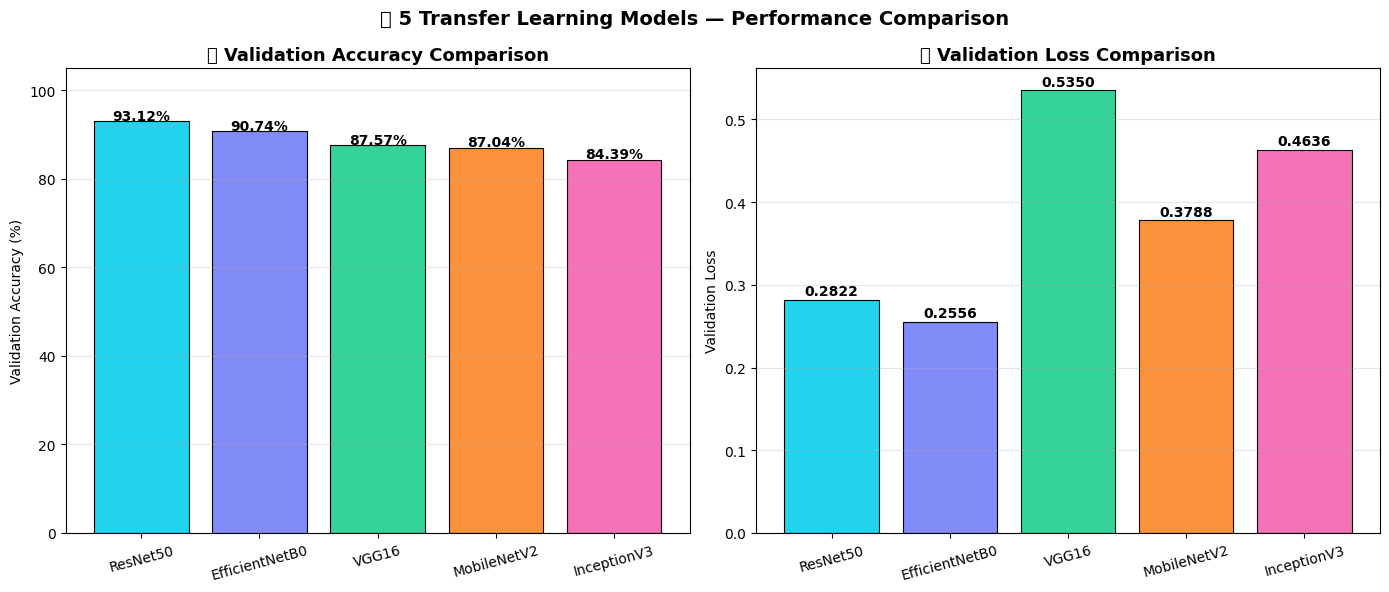

✅ Comparison chart saved: D:\RecycleVision\models\model_comparison.png


In [18]:
# Cell 10 - Final Comparison Table & Bar Chart
print('=' * 65)
print('         🏆 ALL 5 MODELS — TRAINING COMPARISON')
print('=' * 65)

comparison_data = []
model_colors    = ['#22d3ee', '#818cf8', '#34d399', '#fb923c', '#f472b6']

for model_name, history in all_histories.items():
    best_train_acc = max(history.history['accuracy'])     * 100
    best_val_acc   = max(history.history['val_accuracy']) * 100
    best_train_loss = min(history.history['loss'])
    best_val_loss   = min(history.history['val_loss'])
    epochs_trained  = len(history.history['accuracy'])

    comparison_data.append({
        'Model'          : model_name,
        'Train Acc (%)' : round(best_train_acc, 2),
        'Val Acc (%)'   : round(best_val_acc,   2),
        'Train Loss'    : round(best_train_loss, 4),
        'Val Loss'      : round(best_val_loss,   4),
        'Epochs'        : epochs_trained
    })

df_compare = pd.DataFrame(comparison_data)
df_compare = df_compare.sort_values('Val Acc (%)', ascending=False).reset_index(drop=True)

print(df_compare.to_string(index=False))
print('=' * 65)
best_model = df_compare.iloc[0]['Model']
best_acc   = df_compare.iloc[0]['Val Acc (%)']
print(f'🏆 BEST MODEL (Val Accuracy) : {best_model} ({best_acc}%)')
print('=' * 65)

# --- Bar Chart Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Val Accuracy
bars = axes[0].bar(
    df_compare['Model'],
    df_compare['Val Acc (%)'],
    color=model_colors, edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars, df_compare['Val Acc (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('📊 Validation Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# Val Loss
bars2 = axes[1].bar(
    df_compare['Model'],
    df_compare['Val Loss'],
    color=model_colors, edgecolor='black', linewidth=0.8
)
for bar, val in zip(bars2, df_compare['Val Loss']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('📊 Validation Loss Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Validation Loss')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('🏆 5 Transfer Learning Models — Performance Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(MODELS_PATH, 'model_comparison.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'✅ Comparison chart saved: {save_path}')

## 🔲 Cell 11 — Verify All Models Saved

In [19]:
# Cell 11 - Verify All Saved Models
print('=' * 55)
print('💾 SAVED MODELS IN models/ FOLDER')
print('=' * 55)

saved_files = os.listdir(MODELS_PATH)
total_size  = 0

for fname in sorted(saved_files):
    fpath     = os.path.join(MODELS_PATH, fname)
    size_mb   = os.path.getsize(fpath) / (1024 * 1024)
    total_size += size_mb
    print(f'  ✅ {fname:<35} {size_mb:.1f} MB')

print('=' * 55)
print(f'  Total size : {total_size:.1f} MB')
print('=' * 55)
print()
print('=' * 55)
print('   ✅ MODEL TRAINING COMPLETE!')
print('=' * 55)
print(f'  5 models trained and saved')
print(f'  Best model so far : {best_model} ({best_acc:.2f}% val accuracy)')
print()
print('🔜 Next Step: Model Evaluation (04_Model_Evaluation.ipynb)')
print('   → Accuracy, Precision, Recall, F1-Score')
print('   → Confusion Matrix for each model')
print('   → Final best model selection')
print('=' * 55)

💾 SAVED MODELS IN models/ FOLDER
  ✅ EfficientNetB0_confusion_matrix.png 0.1 MB
  ✅ EfficientNetB0_history.png          0.1 MB
  ✅ InceptionV3_confusion_matrix.png    0.1 MB
  ✅ InceptionV3_history.png             0.1 MB
  ✅ MobileNetV2_confusion_matrix.png    0.1 MB
  ✅ MobileNetV2_history.png             0.1 MB
  ✅ ResNet50_ROC_curve.png              0.1 MB
  ✅ ResNet50_confusion_matrix.png       0.1 MB
  ✅ ResNet50_history.png                0.1 MB
  ✅ VGG16_confusion_matrix.png          0.1 MB
  ✅ VGG16_history.png                   0.1 MB
  ✅ all_confusion_matrices.png          0.2 MB
  ✅ all_metrics_comparison.png          0.2 MB
  ✅ efficientnetb0_best.h5              19.7 MB
  ✅ efficientnetb0_model.h5             19.7 MB
  ✅ inceptionv3_best.h5                 95.9 MB
  ✅ inceptionv3_model.h5                95.9 MB
  ✅ mobilenetv2_best.h5                 12.8 MB
  ✅ mobilenetv2_model.h5                12.8 MB
  ✅ model_comparison.png                0.1 MB
  ✅ model_evaluation_